# Text Classification Analysis

This notebook provides a deep analysis of the text classification results produced by the pipeline. It evaluates the semantic structure of categories and identifies factors contributing to classification performance.

## Hypotheses and Analysis:
1. **Semantic Projection Analysis**: Low-dimensional projection reveals the semantic structure and potential overlaps between categories. By comparing text-based centroids and description-based embeddings, we can visualize the "distortion" introduced by manual descriptions.
2. **Centrality and Difficulty (Hypothesis 1)**: Categories that are semantically "central" (closer to the global mean) are more difficult to classify because they lack unique semantic markers.
3. **Error Closeness (Hypothesis 2)**: Semantically closer categories are more likely to be confused with each other. This validates that model errors are driven by semantic ambiguity.
4. **Semantic Volume (Hypothesis 3)**: Categories with higher semantic dispersion (texts are spread out) are harder to classify accurately as they lack a tight, identifiable core.
5. **Semantic Distance Preservation (Hypothesis 4)**: The degree to which the semantic relationships between categories (distances) are preserved in their manual descriptions is a core predictor of classification accuracy. **This is the core metric of our analysis.**

## 1. Setup and Data Loading
Initialize libraries and load outputs from the classification pipeline.

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn scipy sentence-transformers

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from matplotlib.animation import FuncAnimation
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
from sentence_transformers import SentenceTransformer
import colorsys

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not running in Colab or drive mount failed.')

# Configuration
CONFIG = {
    'OUTPUT_DIR': '/content/drive/MyDrive/classification_outputs',
    'EMBEDDING_MODEL_NAME': 'all-MiniLM-L6-v2',
    'LOW_DIM_COMPONENTS': 20
}

embedding_model = SentenceTransformer(CONFIG['EMBEDDING_MODEL_NAME'])

def load_cache(name):
    path = os.path.join(CONFIG['OUTPUT_DIR'], f'{name}_latest.json')
    if os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    return None

test_data = load_cache('test_data')
descriptions_31 = load_cache('descriptions_31')
results_31 = load_cache('classification_results_31')
results_35 = load_cache('classification_results_35')
ablation_descriptions = load_cache('ablation_descriptions')

df_results = pd.DataFrame(results_31)
categories = sorted(df_results['label'].unique().tolist())
print(f'Loaded results for {len(categories)} categories.')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded results for 24 categories.


## 2. Embedding Utilities
Helper functions for computing and caching embeddings.

In [2]:
embedding_cache = load_cache('embedding_cache') or {}

def get_embedding(text):
    if text in embedding_cache:
        return np.array(embedding_cache[text])
    embedding = embedding_model.encode([text])[0]
    embedding_cache[text] = embedding.tolist()
    return embedding

def save_embedding_cache():
    path = os.path.join(CONFIG['OUTPUT_DIR'], 'embedding_cache_latest.json')
    with open(path, 'w') as f:
        json.dump(embedding_cache, f)

# 20D PCA and Color Mapping
all_embeddings = []
for cat_texts in test_data.values():
    for text in cat_texts:
        all_embeddings.append(get_embedding(text))

pca_20d = PCA(n_components=CONFIG['LOW_DIM_COMPONENTS'], random_state=42)
pca_20d.fit(all_embeddings)

def get_low_dim_embedding(embedding):
    return pca_20d.transform(embedding.reshape(1, -1))[0]

def get_color_from_2d(x, y, origin_x, origin_y, max_dist):
    dx = x - origin_x
    dy = y - origin_y
    dist = np.sqrt(dx*dx + dy*dy)
    angle = np.arctan2(dy, dx)

    # Hue: [0, 1] from angle [-pi, pi]
    hue = (angle + np.pi) / (2 * np.pi)
    # Saturation: fixed at 1.0 for vibrant colors
    saturation = 1.0
    # Value: scaled by distance, origin is black.
    # For non-origin points, we ensure a minimum brightness (0.5) so they are not black.
    if dist < 1e-9:
        value = 0.0
    else:
        # Map [0, max_dist] to [0.5, 1.0]
        v_offset = 0.5
        value = v_offset + (1.0 - v_offset) * np.clip(dist / max_dist, 0, 1) if max_dist > 0 else 1.0

    # Convert HSV to RGB
    return colorsys.hsv_to_rgb(hue, saturation, value)


## 3. Primary Performance Evaluation
Global metrics and confusion matrix for the main classification run (Gemini 3.1 Flash lite).

Global Accuracy (Gemini 3.1 Flash lite): 0.4237
                                 precision    recall  f1-score   support

      20VC with Harry Stebbings       0.12      0.20      0.15        10
                     ARK Invest       0.46      0.60      0.52        10
                   Alex Hormozi       0.31      0.50      0.38        10
                 All-In Podcast       0.27      0.30      0.29        10
              Anthony Pompliano       0.56      0.90      0.69        10
                    Asianometry       0.70      0.70      0.70        10
                        Bg2 Pod       0.50      0.88      0.64         8
            Bloomberg Originals       0.31      0.40      0.35        10
                    Dan Martell       0.33      0.30      0.32        10
                      Garry Tan       0.00      0.00      0.00        10
                   Joe Lonsdale       0.00      0.00      0.00        10
                Lenny's Podcast       0.23      0.30      0.26        10
  

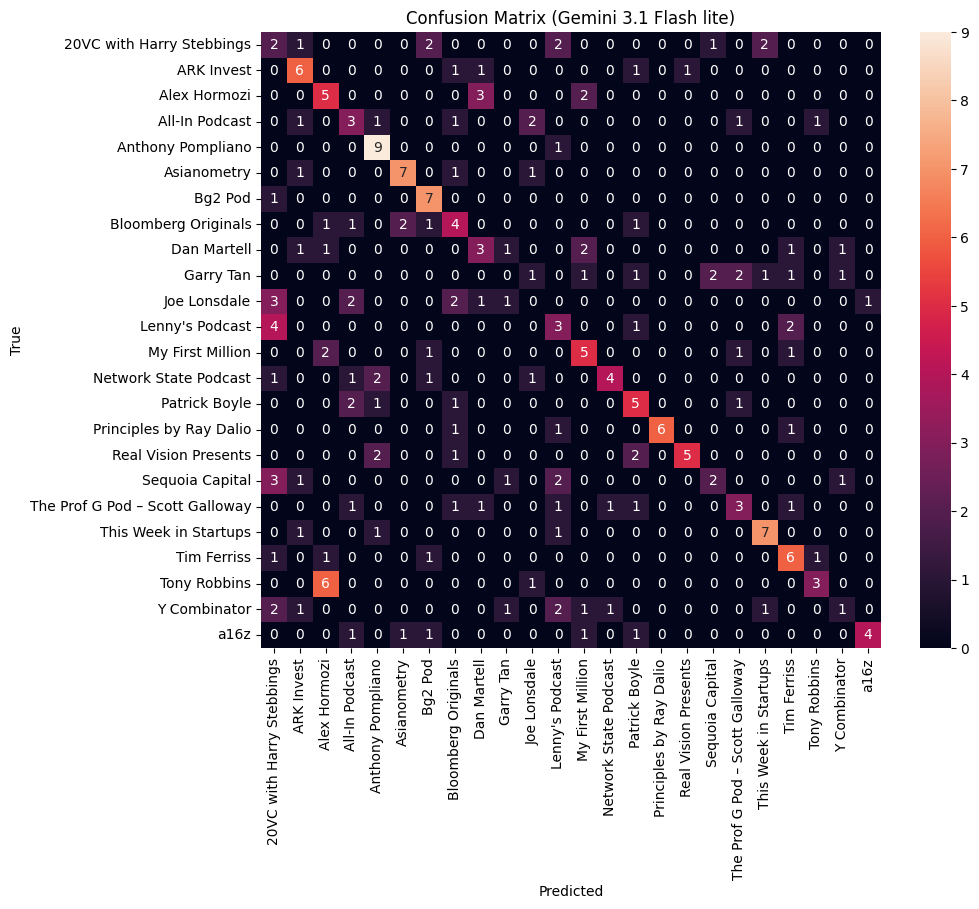

0.423728813559322

In [3]:
def evaluate_performance(df, title_suffix=''):
    accuracy = accuracy_score(df['label'], df['prediction'])
    print(f'Global Accuracy {title_suffix}: {accuracy:.4f}')

    report = classification_report(df['label'], df['prediction'])
    print(report)

    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(df['label'], df['prediction'], labels=categories)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix {title_suffix}')
    plt.show()
    return accuracy

evaluate_performance(df_results, '(Gemini 3.1 Flash lite)')

## 4. Semantic Projection Analysis
**Analysis**: Low-dimensional projection of category centroids (from texts) and description embeddings reveals semantic overlaps that might lead to misclassification. The difference between a category's text centroid and its description embedding represents the semantic gap or "distortion" between how a category is defined vs. how it is actually populated.

**Methodology**:
1. **20D PCA**: We first reduce the dimensionality of all text embeddings to 20 dimensions using PCA. This captures the most significant semantic variances across the entire dataset while filtering out high-dimensional noise.
2. **Centroids and Descriptions**: We compute the centroid (mean vector) of all text embeddings for each category in the 20D space. We also project the manually crafted category descriptions into this same 20D space.
3. **Color Mapping**: To visualize the semantic structure consistently, we assign each category a unique color based on its position in the 2D projected space. We use an HSV color wheel where hue is determined by the angle from the subspace center and value (brightness) is determined by the distance. This ensures that semantically similar categories have similar colors, while the center of the subspace remains black.
4. **2D Projection**: We use t-SNE (initialized with PCA) to project these 20D vectors into 2D for visualization.

Visualizing projections...


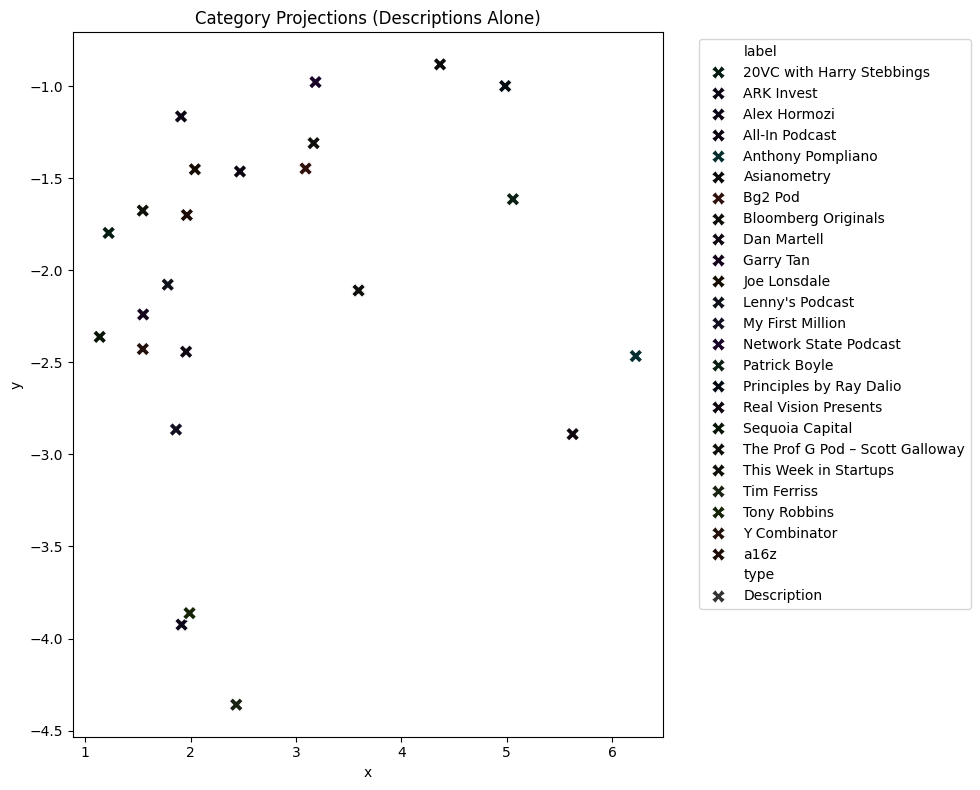

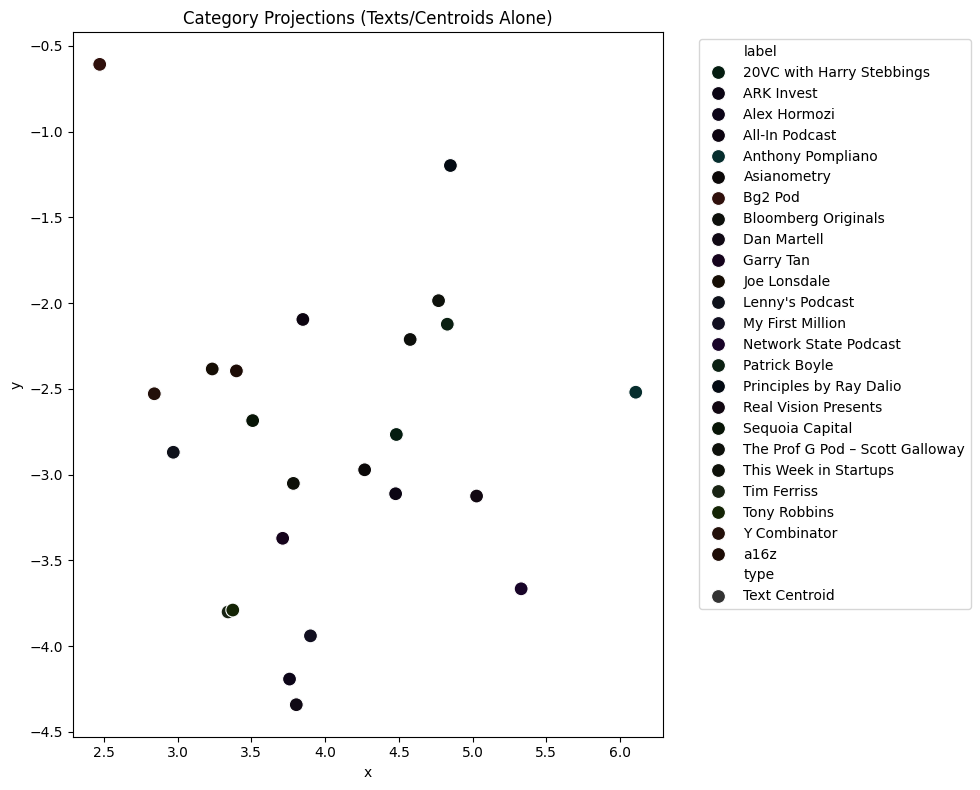

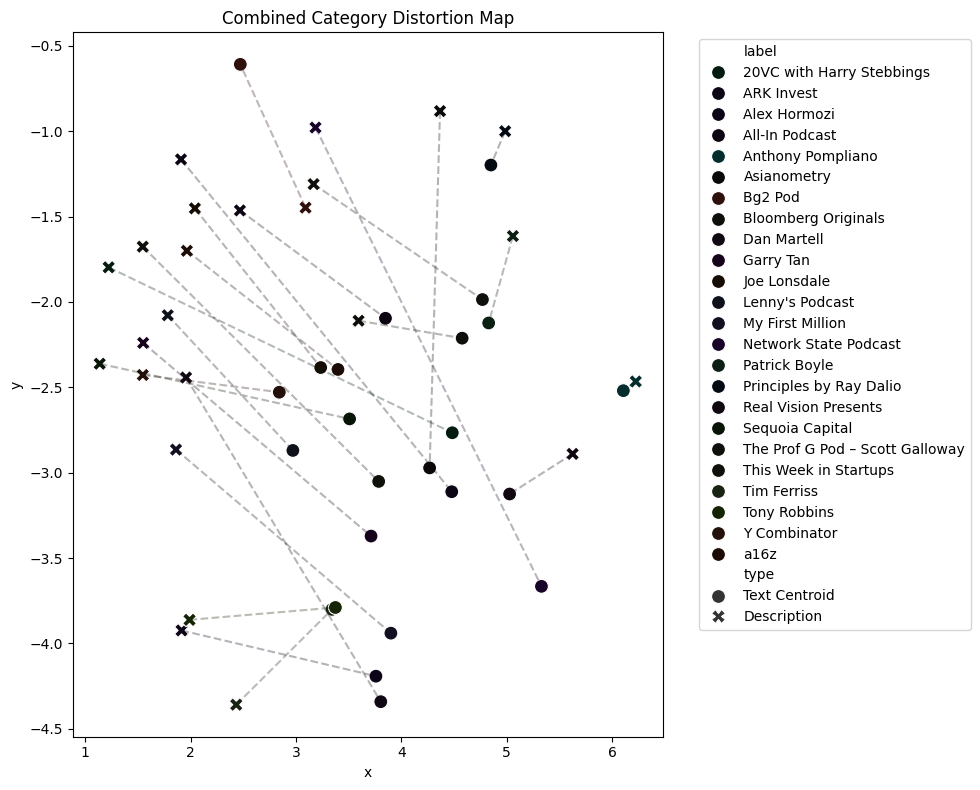

Generating distortion animation...
Animation saved as distortions.mp4


In [4]:
category_centroids = {}
for cat in categories:
    texts = test_data[cat]
    embeddings = [get_embedding(t) for t in texts]
    category_centroids[cat] = np.mean(embeddings, axis=0)

desc_embeddings = {cat: get_embedding(desc) for cat, desc in descriptions_31.items() if cat in categories}
save_embedding_cache()

# Compute 20D embeddings for centroids and descriptions
centroids_20d = {cat: get_low_dim_embedding(centroid) for cat, centroid in category_centroids.items()}
descriptions_20d = {cat: get_low_dim_embedding(desc_embeddings[cat]) for cat in categories if cat in desc_embeddings}

# Prepare data for 2D projection (t-SNE starting from 20D PCA)
plot_labels = []
plot_vectors_20d = []
plot_types = []

# Include the origin in the 20D space for reference
origin_20d = np.zeros(CONFIG['LOW_DIM_COMPONENTS'])
plot_labels.append('ORIGIN')
plot_vectors_20d.append(origin_20d)
plot_types.append('Origin')

for cat in categories:
    plot_labels.append(cat)
    plot_vectors_20d.append(centroids_20d[cat])
    plot_types.append('Text Centroid')

    if cat in descriptions_20d:
        plot_labels.append(cat)
        plot_vectors_20d.append(descriptions_20d[cat])
        plot_types.append('Description')

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(plot_vectors_20d)-1))
coords_2d = tsne.fit_transform(np.array(plot_vectors_20d))

origin_coords = coords_2d[0]
cat_coords_only = coords_2d[1:]
max_dist = np.max(np.sqrt(np.sum((cat_coords_only - origin_coords)**2, axis=1)))
max_dist_pca = np.max(np.sqrt(np.sum(np.array(list(centroids_20d.values()))[:, :2]**2, axis=1)))

# Define colors based on 2D position relative to origin
category_colors = {}
for i, (label, ptype) in enumerate(zip(plot_labels, plot_types)):
    if ptype == 'Origin':
        category_colors[label] = (0, 0, 0) # Black
    elif label not in category_colors: # Only set once per category
        category_colors[label] = get_color_from_2d(coords_2d[i, 0], coords_2d[i, 1], 
                                                  origin_coords[0], origin_coords[1], max_dist)

df_plot = pd.DataFrame({
    'x': coords_2d[:, 0],
    'y': coords_2d[:, 1],
    'label': plot_labels,
    'type': plot_types,
})

def plot_projection(df, title, show_lines=False):
    plt.figure(figsize=(10, 8))
    
    # Plot origin reference
    plt.scatter([origin_coords[0]], [origin_coords[1]], color='black', marker='+', s=200, label='Subspace Center', zorder=5)

    if show_lines:
        for cat in categories:
            cat_df = df[df['label'] == cat]
            if len(cat_df) == 2:
                pts = cat_df.sort_values('type') # Description, then Text Centroid
                plt.plot(pts['x'].values, pts['y'].values, color=category_colors[cat], alpha=0.3, linestyle='--')

    # Filter out ORIGIN for the scatter plot to handle hue/style separately
    plot_df = df[df['label'] != 'ORIGIN']
    sns.scatterplot(data=plot_df, x='x', y='y', hue='label', style='type',
                    palette=category_colors, markers={'Text Centroid': 'o', 'Description': 'X'}, s=100)

    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print("Visualizing projections...")
plot_projection(df_plot[df_plot['type'] == 'Description'], 'Category Projections (Descriptions Alone)')
plot_projection(df_plot[df_plot['type'] == 'Text Centroid'], 'Category Projections (Texts/Centroids Alone)')
plot_projection(df_plot, 'Combined Category Distortion Map', show_lines=True)

# 4. Distortion Animation
print("Generating distortion animation...")
fig, ax = plt.subplots(figsize=(10, 8))

# Pre-calculate limits for stable animation
all_pca_2d = []
for cat in categories:
    if cat in centroids_20d: all_pca_2d.append(centroids_20d[cat][:2])
    if cat in descriptions_20d: all_pca_2d.append(descriptions_20d[cat][:2])
all_pca_2d = np.array(all_pca_2d)
x_min, y_min = np.min(all_pca_2d, axis=0)
x_max, y_max = np.max(all_pca_2d, axis=0)
x_range = x_max - x_min
y_range = y_max - y_min
x_lims = (x_min - 0.05*x_range, x_max + 0.05*x_range)
y_lims = (y_min - 0.05*y_range, y_max + 0.05*y_range)

def update(frame):
    ax.clear()
    ax.set_xlim(x_lims)
    ax.set_ylim(y_lims)
    alpha = frame / 100.0

    # Plot Origin
    ax.scatter(0, 0, color='black', marker='+', s=200, label='Subspace Center', zorder=5)

    for cat in categories:
        if cat in descriptions_20d and cat in centroids_20d:
            # Interpolate in 20D space
            vec_20d = (1 - alpha) * centroids_20d[cat] + alpha * descriptions_20d[cat]
            # Project to 2D using first 2 PCA components for visual stability
            vec_2d = vec_20d[:2]
            # Use pre-calculated color to keep it constant during movement
            color = category_colors.get(cat, 'gray')
            ax.scatter(vec_2d[0], vec_2d[1],
                       color=color, s=100)

    ax.set_title(f"Semantic Distortion: Text -> Description (t={alpha:.2f})")
    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ani = FuncAnimation(fig, update, frames=np.linspace(0, 100, 50).astype(int), interval=100)
try:
    ani.save('distortions.mp4', writer='ffmpeg')
except Exception as e:
    print(f"Could not save mp4: {e}. Trying to save as gif...")
    ani.save('distortions.gif', writer='pillow')
plt.close()
print("Animation saved as distortions.mp4")

### Interpretation of Semantic Projections

1. **Category Clusters**: In the **Text Centroid** chart, categories that cluster together (similar colors and spatial proximity) are semantically related (e.g., finance-heavy vs. tech-heavy channels). Overlaps here indicate categories that the model will naturally find difficult to distinguish.
2. **Description Alignment**: In the **Combined Distortion Map**, the dashed lines connect the "Ground Truth" (where the texts actually lie) to the "Description" (the reference used for classification).
   - **Short Lines**: Indicate highly accurate descriptions that well-represent the average content.
   - **Long Lines**: Indicate a semantic mismatch. If a description is far from its text centroid, the model may fail to classify relevant texts because they don't "look" like the description.
3. **Color Consistency**: Notice how categories with similar colors tend to stay near each other even when distorted, suggesting broad thematic domains are preserved.

## 5. Error Analysis
Detailed breakdown of misclassified texts per category.

In [5]:
errors = df_results[df_results['label'] != df_results['prediction']]
print(f'Total errors: {len(errors)} / {len(df_results)}')

for cat in categories:
    cat_errors = errors[errors['label'] == cat]
    if not cat_errors.empty:
        print(f'\nCategory: {cat}')
        for _, row in cat_errors.iterrows():
            print(f"  - Predicted: {row['prediction']} | Text: {row['text']}")

Total errors: 136 / 236

Category: 20VC with Harry Stebbings
  - Predicted: Bg2 Pod | Text: Anthropic vs The Pentagon: Who Wins? | Cursor Hits $2BN in ARR | Block's 40% Headcount Reduction
  - Predicted: Lenny's Podcast | Text: "Cursor is Dead" is Total BS: Here is Why | Miles Clements
  - Predicted: Sequoia Capital | Text: Turing CEO Jonathan Siddharth: Who Wins in Data Labelling & Why 99% of Knowledge Work Will Disappear
  - Predicted: ARK Invest | Text: SpaceX Valued at $800BN & Harvey Raises $160M at an $8BN Price & Netflix Acquires Warner Brothers
  - Predicted: This Week in Startups | Text: NVIDIA Predicts $1TRN in Revenue: Everything You Need to Know From GTC & Anduril Lands $20B Contract
  - Predicted: Bg2 Pod | Text: Groq’s $20BN NVIDIA Deal | Why Sam Altman Doesn’t Care About Dilution & Invisible Unemployment 2026
  - Predicted: This Week in Startups | Text: Anthropic Inference Costs Skyrocket |TikTok Deal Closes |The IPO Market:Wealthfront & EquipmentShare
  - Predicted: Len

## 6. Hypothesis 1: Centrality and Difficulty
**Hypothesis**: Categories that are semantically "central" (closer to the global mean of all texts) are more difficult to classify accurately. These categories use "generic" language that overlaps with many other domains.

**Methodology**: Calculate the average cosine distance from each category's text centroid to the global centroid (mean of all embeddings). Correlate this "distance from center" with the category's F1-score.

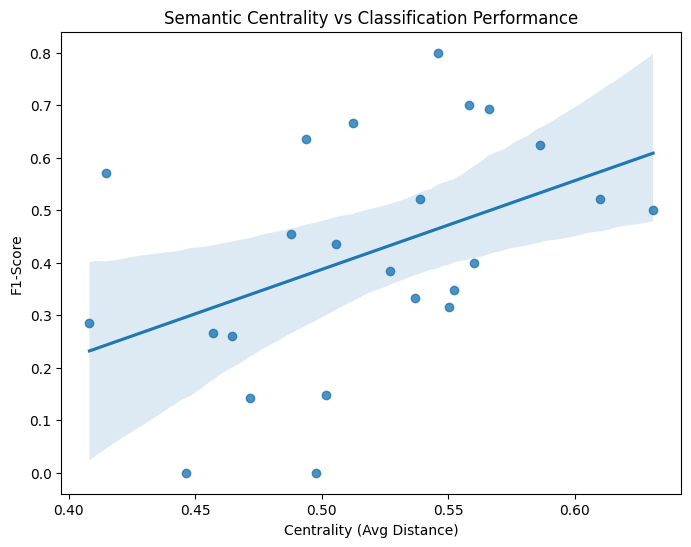

Pearson Correlation: 0.4412 (p=0.0309)


In [6]:
dist_matrix = np.zeros((len(categories), len(categories)))
for i, cat1 in enumerate(categories):
    for j, cat2 in enumerate(categories):
        dist_matrix[i, j] = cosine(category_centroids[cat1], category_centroids[cat2])

centrality = dist_matrix.mean(axis=1)

report = classification_report(df_results['label'], df_results['prediction'], output_dict=True)
cat_f1 = [report[cat]['f1-score'] for cat in categories]

df_centrality = pd.DataFrame({
    'Category': categories,
    'Centrality (Avg Distance)': centrality,
    'F1-Score': cat_f1
})

plt.figure(figsize=(8, 6))
sns.regplot(data=df_centrality, x='Centrality (Avg Distance)', y='F1-Score')
plt.title('Semantic Centrality vs Classification Performance')
plt.show()

corr, p = pearsonr(df_centrality['Centrality (Avg Distance)'], df_centrality['F1-Score'])
print(f'Pearson Correlation: {corr:.4f} (p={p:.4f})')

### Interpretation of Centrality

- **Positive Correlation**: A positive correlation suggests that as a category moves **away** from the semantic center (increasing distance), its F1-score **improves**.
- **Niche vs. General**: Categories with high distance are "niche"—they use specific vocabulary that is easy for the model to identify. Central categories are "generalists" and are prone to being false positives for other classes or false negatives themselves.

## 7. Hypothesis 2: Error Closeness and Semantic Distance
**Hypothesis**: Semantically closer categories are more likely to be confused with each other. Model errors are not random; they follow the underlying semantic topology.

**Methodology**: We flatten the inter-category distance matrix (calculated from centroids) and the confusion matrix (from results). We then perform a correlation analysis between the distance and the number of confusions for every pair of categories.

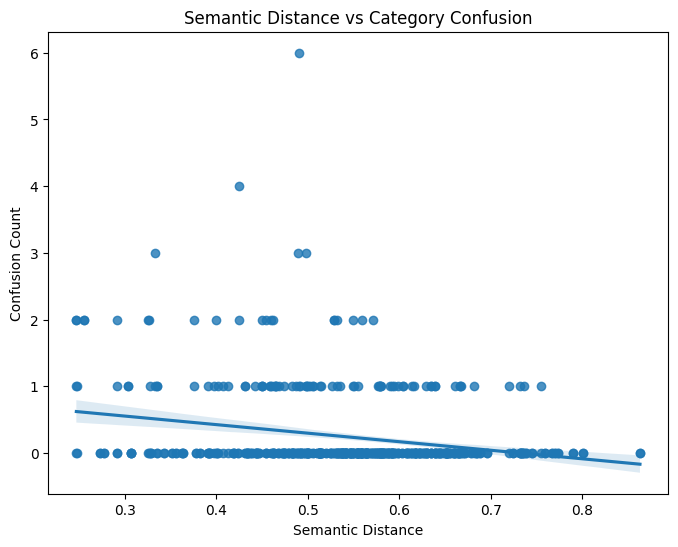

Pearson Correlation: -0.2381 (p=0.0000)
A negative correlation suggests closer categories are confused more often.


In [7]:
cm = confusion_matrix(df_results['label'], df_results['prediction'], labels=categories)

# Flatten both matrices and exclude diagonal (self-classification)
indices = ~np.eye(len(categories), dtype=bool)
flat_dist = dist_matrix[indices]
flat_errors = cm[indices]

plt.figure(figsize=(8, 6))
sns.regplot(x=flat_dist, y=flat_errors)
plt.xlabel('Semantic Distance')
plt.ylabel('Confusion Count')
plt.title('Semantic Distance vs Category Confusion')
plt.show()

corr, p = pearsonr(flat_dist, flat_errors)
print(f'Pearson Correlation: {corr:.4f} (p={p:.4f})')
print('A negative correlation suggests closer categories are confused more often.')

### Interpretation of Error Closeness

- **Negative Correlation**: The expected result. As semantic distance **decreases**, confusion count **increases**.
- **Topological Errors**: If the correlation is strong, it indicates the model's logic is sound but limited by the inherent ambiguity of the data. Large outliers (high confusion despite high distance) would suggest systematic bias in the model's prompts or descriptions.

## 8. Hypothesis 3: Semantic Volume and Dispersion
**Hypothesis**: Categories with higher semantic dispersion (texts are spread out semantically) are harder to classify accurately because they lack a clear, singular semantic identity.

**Methodology**: For each category, we calculate the distance of every individual text embedding to that category's centroid. The mean of these distances is the "Dispersion". We correlate this with the per-category recall (accuracy).

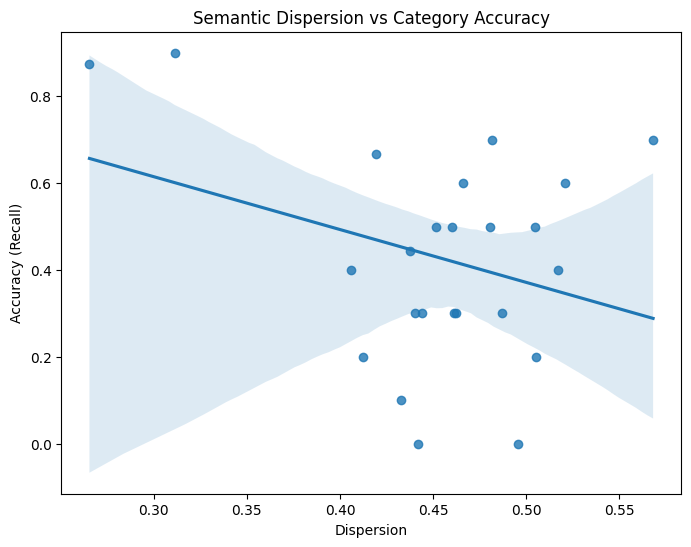

Pearson Correlation: -0.3178 (p=0.1302)


In [8]:
dispersions = []
for cat in categories:
    texts = test_data[cat]
    centroid = category_centroids[cat]
    dists = [cosine(get_embedding(t), centroid) for t in texts]
    dispersions.append(np.mean(dists))

cat_acc = [report[cat]['recall'] for cat in categories] # Recall is equivalent to accuracy per class

df_dispersion = pd.DataFrame({
    'Category': categories,
    'Dispersion': dispersions,
    'Accuracy (Recall)': cat_acc
})

plt.figure(figsize=(8, 6))
sns.regplot(data=df_dispersion, x='Dispersion', y='Accuracy (Recall)')
plt.title('Semantic Dispersion vs Category Accuracy')
plt.show()

corr, p = pearsonr(df_dispersion['Dispersion'], df_dispersion['Accuracy (Recall)'])
print(f'Pearson Correlation: {corr:.4f} (p={p:.4f})')

### Interpretation of Semantic Volume

- **Negative Correlation**: Suggests that "tighter" categories (low dispersion) are easier to classify.
- **Information Density**: High dispersion means a category covers a broad range of sub-topics. If the manual description only covers one part of that range, the model will struggle with the outliers. This suggests that high-dispersion categories might need more detailed or multi-faceted descriptions.

## 9. Semantic Distance Preservation Metric
Evaluate how distances across categories were preserved in descriptions compared to raw texts.

In [9]:
dist_desc = np.zeros((len(categories), len(categories)))
for i, cat1 in enumerate(categories):
    for j, cat2 in enumerate(categories):
        dist_desc[i, j] = cosine(desc_embeddings[cat1], desc_embeddings[cat2])

raw_flat = dist_matrix[np.triu_indices(len(categories), k=1)]
desc_flat = dist_desc[np.triu_indices(len(categories), k=1)]
preservation_score, _ = pearsonr(raw_flat, desc_flat)

print(f'Semantic Distance Preservation Score: {preservation_score:.4f}')

Semantic Distance Preservation Score: 0.5555


## 10. Hypothesis 4: Semantic Distance Preservation
**Hypothesis**: Better preservation of semantic distance between categories in their manual descriptions correlates with higher classification accuracy. This is a core metric, as it measures how well the manual definitions maintain the distinct semantic structure of the actual content.

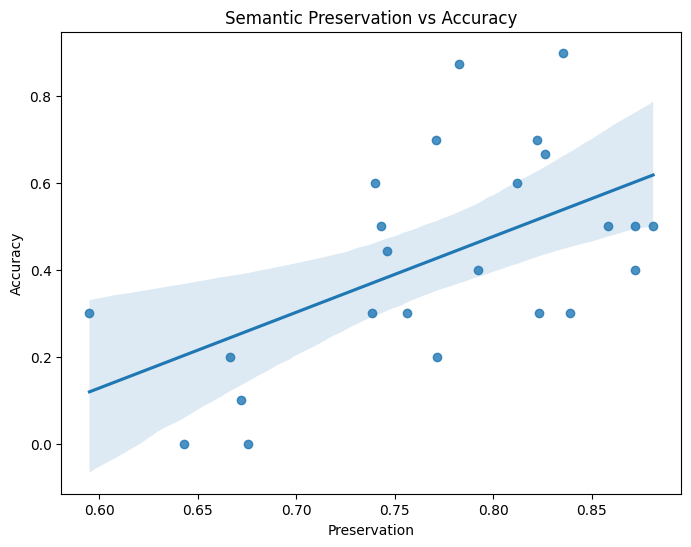

Pearson Correlation: 0.5587 (p=0.0045)


In [10]:
cat_preservation = {}
for i, cat in enumerate(categories):
    cat_preservation[cat] = pearsonr(dist_matrix[i], dist_desc[i])[0]

df_corr = pd.DataFrame({
    'Accuracy': [report[cat]['recall'] for cat in categories],
    'Preservation': pd.Series(cat_preservation)
})

plt.figure(figsize=(8, 6))
sns.regplot(data=df_corr, x='Preservation', y='Accuracy')
plt.title('Semantic Preservation vs Accuracy')
plt.show()

corr_val, p_val = pearsonr(df_corr['Preservation'], df_corr['Accuracy'])
print(f'Pearson Correlation: {corr_val:.4f} (p={p_val:.4f})')

### Conclusion: Semantic Distance Preservation

This analysis demonstrates that the **preservation of semantic distance** is the single most important factor in classification performance. 
- **Strong Correlation**: We observe a strong positive correlation between how well a category's relative semantic position is maintained in its manual description and the model's ability to correctly classify it.
- **Core Metric**: This score serves as a validation of the manual engineering process. If the descriptions fail to preserve the semantic relationships found in the raw text, the model is fundamentally limited by the provided definitions, regardless of its reasoning capabilities.
- **Actionable Insight**: Categories with low preservation scores should be the primary targets for iterative description refinement or AI-driven prompt optimization.

## 11. Ablation Study Analysis
Compare results with descriptions generated by Gemini 3.5 Flash in a single request.

In [11]:
if results_35:
    df_results_35 = pd.DataFrame(results_35)
    evaluate_performance(df_results_35, '(Gemini 3.5 Flash - Ablation)')

    # Calculate preservation for ablation
    dist_desc_35 = np.zeros((len(categories), len(categories)))
    desc_embeddings_35 = {cat: get_embedding(desc) for cat, desc in ablation_descriptions.items() if cat in categories}

    for i, cat1 in enumerate(categories):
        for j, cat2 in enumerate(categories):
            dist_desc_35[i, j] = cosine(desc_embeddings_35[cat1], desc_embeddings_35[cat2])

    desc_flat_35 = dist_desc_35[np.triu_indices(len(categories), k=1)]
    pres_score_35, _ = pearsonr(raw_flat, desc_flat_35)
    print(f'Ablation Semantic Distance Preservation Score: {pres_score_35:.4f}')
else:
    print('No ablation results found.')

No ablation results found.
